In [1]:
import sys
import platform
from os.path import join, exists, abspath, dirname
from os import getcwd, makedirs
from glob import glob

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps, cm
from matplotlib import colors as mcolors
import scipy
import seaborn as sns
from statsmodels.stats.anova import AnovaRM

import h5py

from tqdm import tqdm

In [2]:
dir_current = getcwd().replace('\\','/')

tmp = dir_current.split('/')
idx = [ii for ii, s in enumerate(tmp) if s=='github'][0]

dir_git = '/'.join(tmp[:idx+1])
dir_git

'/Users/sungbeenpark/github'

In [3]:
dname = join(dir_git,'SeqSpatialSupp_fMRI')
sys.path.append(dname)
from SSS import deal_spm
from SSS import util as su
from SSS import plot as splt
from SSS import stat as sstat

In [4]:
import warnings

---

In [5]:
mpl.rcParams['font.family'] = 'Helvetica'

---

In [6]:
dir_behav = su.get_dir_behav()

In [7]:
# list_sn = su.get_list_sn()
list_sn = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']
list_sn

['01', '02', '03', '04', '05', '06', '07', '08', '09', '10']

---

## motor sequences
- 32451
- 35124
- 13254
- 14523
## visual cues
- letter
- spatial

---

## 1. Repetition

 | | symbol | trial$_{t-1}$ | trial $_{t}$ |
 |---------|---------|---------|---------|
 | Both-Rep$_{c}$ <br> (within-$c$ repetition) | <span style="color:#00008B">$B_{c}$</span> | $(s,c)$ | $(s,c)$ |
 | Cue-Rep$_{c}$ <br> (within-$c$ no-repetition) | <span style="color:#0000FF">$C_{c}$</span> | $(\neg s,c)$ | $(s,c)$ |
 | Seq-Rep$_{c}$ <br> (between-$c$ repetition) | <span style="color:#8B0000">$S_{c}$</span> | $(s,\neg c)$ | $(s,c)$ |
 | Non-Rep$_{c}$ <br> (between-$c$ no-repetition) | <span style="color:#FF0000">$N_{c}$</span> | $(\neg s,\neg c)$ | $(s,c)$ |

$Trial State=(s,c)$:\
$ s=0: 32451 $, $ s=1: 35124 $, $s=2: 13254 $, $s=3: 14523$ \
$ c=0: Letter $, $ c=1: Spatial $

In [8]:
def seq2seqType(seq):
    if seq=='32451':
        res = 0
    elif seq=='35124':
        res = 1
    elif seq=='13254':
        res = 2
    elif seq=='14523':
        res = 3
    else:
        res = -1

    return res

In [9]:
def get_behav_df(sn):
    subj = 'B'+sn
    
    fname = join(dir_behav,'sub-%s/sslb2_%s.dat'%(subj,subj))
    df_tmp = pd.read_csv(fname, delimiter='\t')
    
    lines = {
        'subj':[], 'BN':[], 'TN':[], 'cueType':[], 'seqType':[], 
        'isError':[], 'point':[], 'MT':[], 'RT':[], 
        'TimeThresh':[], 'TimeThreshSuper':[] 
    }
    for idx, line in df_tmp.iterrows():
        lines['subj'].append(subj)
        lines['TN'].append(line.TN.astype(int))
        lines['BN'].append(line.BN.astype(int))
        lines['cueType'].append(line.cueType.astype(int))
        seq = ''.join(map(str,[line['press%1d'%i] for i in range(5)]))
        lines['seqType'].append(seq2seqType(seq))
        lines['isError'].append(line.isError.astype(int))
        lines['point'].append(line.point.astype(int))
        lines['MT'].append(line.MT.astype(int))
        lines['RT'].append(line.RT.astype(int))
        lines['TimeThresh'].append(line.timeThreshold.astype(int))
        lines['TimeThreshSuper'].append(line.timeThresholdSuper.astype(int))
    df = pd.DataFrame(lines)

    return df

In [10]:
dg = pd.DataFrame()

# with warnings.catch_warnings():
#     warnings.simplefilter('ignore')
for sn in tqdm(list_sn):
    df = get_behav_df(sn)
    df_tmp = df.copy()

    df_tmp['cueType-1'] = df.cueType.shift(1)
    df_tmp['seqType-1'] = df.seqType.shift(1)
    df_tmp['RT-1'] = df.RT.shift(1)
    df_tmp['MT-1'] = df.MT.shift(1)
    
    df_tmp = df_tmp.drop(0)
    df_tmp = df_tmp.reset_index(drop=True)
    df_tmp['cueType-1'] = df_tmp['cueType-1'].astype(int)
    df_tmp['seqType-1'] = df_tmp['seqType-1'].astype(int)
    df_tmp['MT-1'] = df_tmp['MT-1'].astype(int)
    df_tmp['RT-1'] = df_tmp['RT-1'].astype(int)

    # df_tmp['cueType-1'] = df_tmp['cueType-1'].astype(int)
    
    ## default condition = NRep
    df_tmp['cond'] = 'Between No-Rep'
    ## other conditions
    df_tmp.loc[(df_tmp.cueType==df_tmp['cueType-1'])&(df_tmp.seqType==df_tmp['seqType-1']),'cond'] = 'Within Rep'
    df_tmp.loc[(df_tmp.cueType==df_tmp['cueType-1'])&(df_tmp.seqType!=df_tmp['seqType-1']),'cond'] = 'Within No-Rep'
    df_tmp.loc[(df_tmp.cueType!=df_tmp['cueType-1'])&(df_tmp.seqType==df_tmp['seqType-1']),'cond'] = 'Between Rep'
    
    df_tmp['Seq_Rep']=[False if 'No-' in cond else True for cond in df_tmp.cond]
    df_tmp['Cue_Rep']=['Within' if 'Within' in cond else 'Between' for cond in df_tmp.cond]

    dg = pd.concat([dg,df_tmp])
dg

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.11it/s]


,subj,BN,TN,cueType,seqType,isError,point,MT,RT,TimeThresh,TimeThreshSuper,cueType-1,seqType-1,RT-1,MT-1,cond,Seq_Rep,Cue_Rep
0,B01,1,2,0,0,1,-1,1058,300,2000,1000,0,2,384,1648,Within No-Rep,False,Within
1,B01,1,3,0,3,0,1,1428,386,2000,1000,0,0,300,1058,Within No-Rep,False,Within
2,B01,1,4,0,3,0,1,1452,306,2000,1000,0,3,386,1428,Within Rep,True,Within
3,B01,1,5,0,0,1,-1,1288,322,2000,1000,0,3,306,1452,Within No-Rep,False,Within
4,B01,1,6,1,3,0,1,1336,310,2000,1000,0,0,322,1288,Between No-Rep,False,Between
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,B10,8,61,0,3,0,3,882,280,1094,924,1,1,418,850,Between No-Rep,False,Between
515,B10,8,62,0,1,0,3,924,314,1094,924,0,3,280,882,Within No-Rep,False,Within
516,B10,8,63,0,0,0,3,918,324,1094,924,0,1,314,924,Within No-Rep,False,Within
517,B10,8,64,0,0,0,3,882,480,1094,924,0,0,324,918,Within Rep,True,Within


In [11]:
## the number of conditions
conds = dg.cond.unique()
for sn in list_sn:
    subj = 'B'+sn
    tmp = dg[dg.subj==subj]
    for cond in dg.cond.unique():
        print(subj, cond, len(tmp[tmp.cond==cond]))
    print('==========================')

B01 Within No-Rep 196
B01 Within Rep 64
B01 Between No-Rep 194
B01 Between Rep 65
B02 Within No-Rep 196
B02 Within Rep 64
B02 Between No-Rep 194
B02 Between Rep 65
B03 Within No-Rep 194
B03 Within Rep 64
B03 Between No-Rep 197
B03 Between Rep 64
B04 Within No-Rep 194
B04 Within Rep 64
B04 Between No-Rep 197
B04 Between Rep 64
B05 Within No-Rep 196
B05 Within Rep 64
B05 Between No-Rep 194
B05 Between Rep 65
B06 Within No-Rep 194
B06 Within Rep 64
B06 Between No-Rep 197
B06 Between Rep 64
B07 Within No-Rep 196
B07 Within Rep 64
B07 Between No-Rep 194
B07 Between Rep 65
B08 Within No-Rep 194
B08 Within Rep 64
B08 Between No-Rep 197
B08 Between Rep 64
B09 Within No-Rep 196
B09 Within Rep 64
B09 Between No-Rep 194
B09 Between Rep 65
B10 Within No-Rep 194
B10 Within Rep 64
B10 Between No-Rep 197
B10 Between Rep 64


In [12]:
dh = dg[dg.isError==0].pivot_table(values=['MT','RT'], index='subj', columns=['Cue_Rep','Seq_Rep'], aggfunc='median')
dh

MT                              RT                     
Cue_Rep Between          Within         Between        Within       
Seq_Rep   False   True    False   True    False  True   False  True 
subj                                                                
B01       982.0   971.0  1004.0   946.0   306.0  307.0  300.0  293.0
B02       540.0   530.0   550.0   558.0   304.0  312.0  312.0  306.0
B03       438.0   442.0   450.0   443.0   271.0  282.0  268.0  270.0
B04       658.0   670.0   640.0   649.0   392.0  386.0  388.0  376.0
B05       753.0   740.0   761.0   744.0   360.0  366.0  375.0  368.0
B06       568.0   554.0   590.0   570.0   246.0  268.0  248.0  258.0
B07       780.0   766.0   764.0   778.0   616.0  604.0  500.0  466.0
B08       824.0   846.0   826.0   862.0   460.0  458.0  429.0  434.0
B09      1248.0  1304.0  1276.0  1268.0   336.0  361.0  332.0  336.0
B10      1159.0  1147.0  1116.0  1050.0   322.0  319.0  328.0  340.0

In [13]:
def get_df_groupby(df=dg, by=['subj','cueType','cond'], successed=True, estimate='mean'):
    if successed:
        dg = df[df.isError==0]
    else:
        dg = df

    Ns = dg.groupby(by).count().reset_index().BN
    if estimate=='mean':
        dg_groupby = dg.groupby(by)[['isError','MT','RT']].mean().reset_index()
    elif estimate=='median':
        dg_groupby = dg.groupby(by)[['isError','MT','RT']].median().reset_index()

    dg_groupby['N'] = Ns
    
    return dg_groupby

In [14]:
# estimate = 'mean'
estimate = 'median'

In [15]:
dg_groupby = get_df_groupby(df=dg, by=['subj','Cue_Rep','Seq_Rep'], successed=True, estimate=estimate)
dg_groupby

,subj,Cue_Rep,Seq_Rep,isError,MT,RT,N
0,B01,Between,False,0.0,982.0,306.0,141
1,B01,Between,True,0.0,971.0,307.0,42
2,B01,Within,False,0.0,1004.0,300.0,147
3,B01,Within,True,0.0,946.0,293.0,54
4,B02,Between,False,0.0,540.0,304.0,146
5,B02,Between,True,0.0,530.0,312.0,51
6,B02,Within,False,0.0,550.0,312.0,149
7,B02,Within,True,0.0,558.0,306.0,49
8,B03,Between,False,0.0,438.0,271.0,188
9,B03,Between,True,0.0,442.0,282.0,63


In [16]:
hue_order = [True,False]
order = ['Within','Between']
palette = ['#27afaf','#af2727']

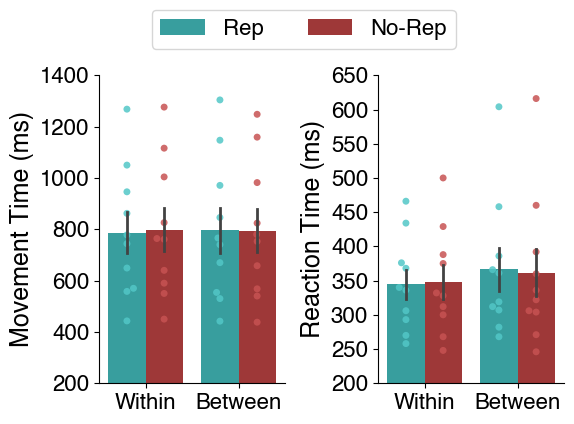

In [17]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(6,4))

for ii, feature in enumerate(['MT','RT']):
    ax = axs[ii]
    sns.swarmplot(
        data=dg_groupby,
        x='Cue_Rep', order=order,
        y=feature,
        hue='Seq_Rep', hue_order=hue_order, dodge=True,
        edgecolor='black',
        palette=['#52c7c7','#c75252'], alpha=0.85,
        ax=ax, zorder=2
    )
    g = sns.barplot(
        data=dg_groupby,
        x='Cue_Rep', order=order,
        y=feature, estimator='mean',
        hue='Seq_Rep', hue_order=hue_order,
        errorbar='se', capsize=0., err_kws={'linewidth': 2.0},
        palette=palette,
        ax=ax, zorder=1
    )
    handles, labels = g.get_legend_handles_labels()
    ax.legend().remove()
    
#     # g.grid(axis='y')
    if ii == 0:
        ylabel = 'Movement Time (ms)'
        g.set_ylim(300,1350)
        g.legend(
            handles[2:], ['Rep','No-Rep'],
            loc='lower center', bbox_to_anchor=(1.1, 1.05),
            ncol=2, fontsize=16
        )
    elif ii == 1:
        ylabel = 'Reaction Time (ms)'
        g.set_ylim(200,650)
    g.set_ylabel(ylabel, fontsize=18)

    g.set_xlabel('')
    xticks = g.get_xticks()
    g.set_xticks(xticks)
    xticklabels = g.get_xticklabels()
    g.set_xticklabels(xticklabels, fontsize=16)
    # g.set_ylabel(ylabel,fontsize=20)
    yticks = g.get_yticks().astype(int)
    g.set_yticks(yticks)
    g.set_yticklabels(yticks, fontsize=16)
#     # g.set_title('session %s'%sess,fontsize=16)
    g.spines['right'].set_visible(False)
    g.spines['top'].set_visible(False)

plt.subplots_adjust(wspace=0.5)
# # fig.tight_layout()

In [18]:
for ii, value in enumerate(['MT','RT']):
    print(value)
    ax = axs[ii]
    for jj, cc in enumerate(['Within','Between']):
        a = dg_groupby[(dg_groupby.Cue_Rep==cc)&(dg_groupby.Seq_Rep==True)][value].astype(float)
        b = dg_groupby[(dg_groupby.Cue_Rep==cc)&(dg_groupby.Seq_Rep==False)][value].astype(float)
        res = scipy.stats.ttest_rel(a,b,alternative='two-sided')
        tval = res.statistic
        pval = res.pvalue
        print(cc, 't(%d)=%.4f (%sp=%.3e)'%(res.df, tval, sstat.convert_pval_to_star(pval), pval))

MT
Within t(9)=-1.0918 (nsp=3.033e-01)
Between t(9)=0.2778 (nsp=7.875e-01)
RT
Within t(9)=-0.7792 (nsp=4.558e-01)
Between t(9)=1.3289 (nsp=2.166e-01)


In [19]:
# fig.savefig(
#     join('/mnt/f/SeqSpatialSupp_fMRI/behav.png'),
#     dpi=300, facecolor=[1,1,1,1], bbox_inches = "tight"
# )

Error Rate

In [20]:
df = pd.DataFrame(columns=['subj', 'error_rate'])
for ii, sn in enumerate(list_sn):
    subj = 'B'+sn
    error_rate = dg[dg.subj==subj].isError.mean()
    line = {'subj':subj, 'error_rate':error_rate}
    df = pd.concat([df, pd.Series(line).to_frame().T], ignore_index=True)
df

,subj,error_rate
0,B01,0.260116
1,B02,0.238921
2,B03,0.044316
3,B04,0.22736
4,B05,0.065511
5,B06,0.123314
6,B07,0.104046
7,B08,0.198459
8,B09,0.138728
9,B10,0.148362


Sequences

In [21]:
dh = dg[dg.isError==0].pivot_table(values=['MT','RT'], index='subj', columns='seqType', aggfunc='median')
dh

MT                             RT                     
seqType       0       1       2       3      0      1      2      3
subj                                                               
B01       794.0  1114.0  1014.0   959.0  320.0  312.0  285.0  285.0
B02       510.0   526.0   633.0   561.0  331.0  308.0  310.0  294.0
B03       456.0   424.0   448.0   436.0  268.0  268.0  270.0  276.0
B04       637.0   618.0   658.0   686.0  364.0  414.0  399.0  386.0
B05       753.0   732.0   750.0   768.0  384.0  381.0  342.0  363.0
B06       566.0   542.0   627.0   564.0  306.0  279.0  194.0  192.0
B07       788.0   720.0   754.0   772.0  590.0  588.0  517.0  490.0
B08       785.0   916.0   930.0   722.0  468.0  450.0  428.0  443.0
B09      1158.0  1252.0  1190.0  1444.0  376.0  366.0  304.0  316.0
B10      1064.0  1130.0  1134.0  1162.0  374.0  330.0  306.0  292.0

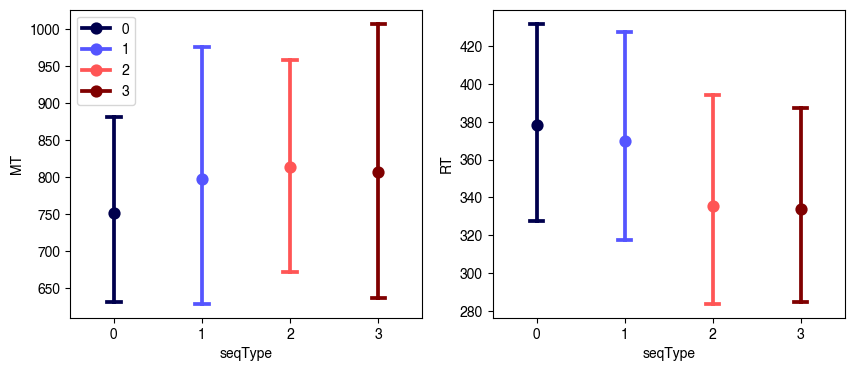

In [22]:
fig, axs = plt.subplots(ncols=2, figsize=(10,4))

for ii, y in enumerate(['MT','RT']):
    ax = axs[ii]
    g = sns.pointplot(
        data=dh.stack(level=1, future_stack=True).reset_index(),
        x='seqType', y=y,
        hue='seqType', palette=cm.seismic,
        capsize=0.15,
        ax=ax
    )
    g.legend()
    if ii!=0:
        g.legend().remove()

## paired t-test (Rep vs. No-Rep)

#### i) Comparing different cues

In [23]:
df = get_df_groupby(df=dg, by=['subj','cueType'], successed=True, estimate='median')
df

,subj,cueType,isError,MT,RT,N
0,B01,0,0.0,1016.0,302.0,205
1,B01,1,0.0,936.0,298.0,179
2,B02,0,0.0,560.0,318.0,201
3,B02,1,0.0,538.0,302.0,194
4,B03,0,0.0,447.0,268.0,248
5,B03,1,0.0,438.0,274.0,248
6,B04,0,0.0,640.0,380.0,194
7,B04,1,0.0,652.0,402.0,207
8,B05,0,0.0,748.0,360.0,245
9,B05,1,0.0,756.0,378.0,240


In [24]:
for estimate in ["mean", "median"]:
    print(estimate)
    df = get_df_groupby(df=dg, by=['subj','cueType'], successed=True, estimate=estimate)
    for value in ['MT','RT']:
        print('== %s =='%value)
        a = df[df.cueType==0][value].astype(float)
        b = df[df.cueType==1][value].astype(float)
        tmp = a.values-b.values
        print('µ(L) = %.2f sec   µ(S) = %.2f sec    ratio: %.4f'%(a.mean(), b.mean(), a.mean()/b.mean()))
        print('µ(L)-µ(S) = %.2f sec (ratio: %.3f)   σ = %.2f sec'%(tmp.mean(), tmp.mean()/b.mean(), scipy.stats.sem(tmp)))
        res = scipy.stats.ttest_rel(a,b,alternative='two-sided')
        tval = res.statistic
        pval = res.pvalue
        print('t(%d)=%.4f (%sp=%.3e)'%(res.df, tval, sstat.convert_pval_to_star(pval), pval))
    print('')

mean
== MT ==
µ(L) = 872.59 sec   µ(S) = 844.08 sec    ratio: 1.0338
µ(L)-µ(S) = 28.51 sec (ratio: 0.034)   σ = 10.82 sec
t(9)=2.6360 (*p=2.709e-02)
== RT ==
µ(L) = 368.36 sec   µ(S) = 368.70 sec    ratio: 0.9991
µ(L)-µ(S) = -0.34 sec (ratio: -0.001)   σ = 6.93 sec
t(9)=-0.0490 (nsp=9.620e-01)

median
== MT ==
µ(L) = 804.80 sec   µ(S) = 779.90 sec    ratio: 1.0319
µ(L)-µ(S) = 24.90 sec (ratio: 0.032)   σ = 10.60 sec
t(9)=2.3483 (*p=4.343e-02)
== RT ==
µ(L) = 357.20 sec   µ(S) = 353.50 sec    ratio: 1.0105
µ(L)-µ(S) = 3.70 sec (ratio: 0.010)   σ = 5.42 sec
t(9)=0.6831 (nsp=5.117e-01)



---
---

---